In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [79]:
## Read the Dataset
df = pd.read_csv('heights.csv')
df.head()


,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

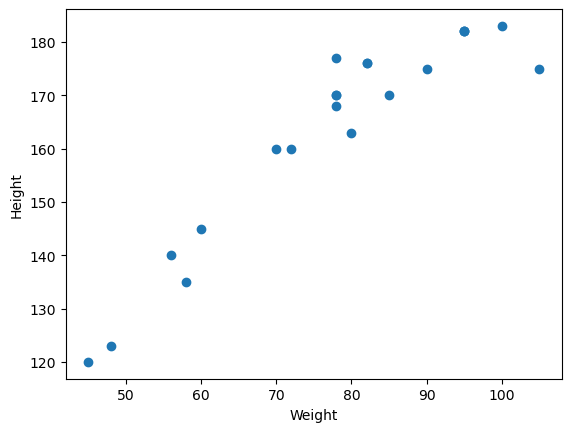

In [80]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [81]:
### Divide the dataset
X = df[['Weight']] ## independent feature
y = df['Height']  ## Dependent feature

In [82]:
## Train and test split the data
from sklearn.model_selection import train_test_split

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [84]:
X.shape


(21, 1)

In [85]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((16, 1), (5, 1), (16,), (5,))

In [86]:
X_train.head()

,Weight
5,78
11,95
3,60
18,78
16,100


In [87]:
## Standarize the dataset train indepedent data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [88]:
X_train.head()

,Weight
5,78
11,95
3,60
18,78
16,100


In [89]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

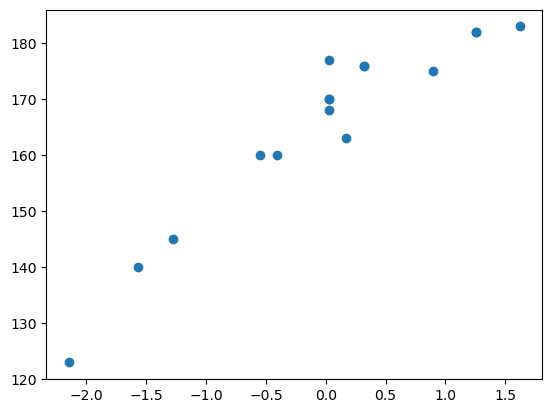

In [90]:
plt.scatter(X_train,y_train)

In [91]:
## Train our simple linear Regression Model
from sklearn.linear_model import LinearRegression

In [92]:
regressor = LinearRegression()

In [93]:
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
print("The slope of weight is",regressor.coef_)
print("The intercept : ",regressor.intercept_)


The slope of weight is [15.49525097]
The intercept :  165.625


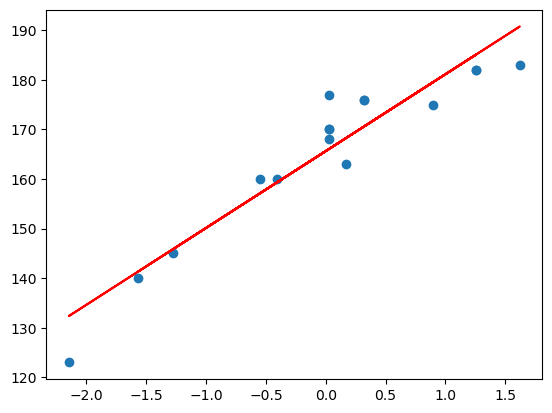

In [95]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

In [96]:
y_pred_test = regressor.predict(X_test)
y_pred_test,y_test

(array([128.99647281, 173.90501189, 196.35928144, 143.59174801,
        185.13214667]),
 0     120
 17    170
 15    175
 1     135
 8     182
 Name: Height, dtype: int64)

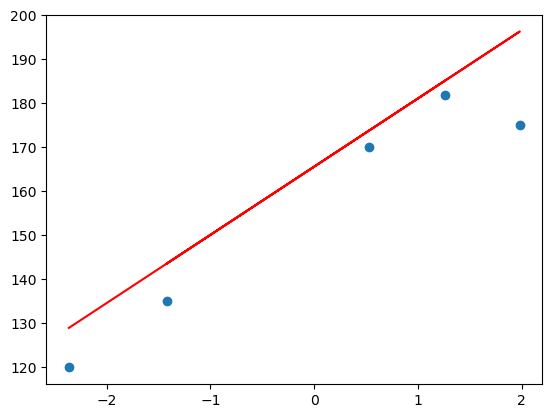

In [97]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

## Perform Metrices 
## MSE,MAE,RMSE
## R Sqaure and adjusted R square

In [98]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [99]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

127.20660420013041
9.19693216307112
11.278590523648353


In [100]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

In [101]:
score

0.7857897679507436

In [102]:
## Adjusted r square

1-(1-score)*len((y_test)-1) / (len(y_test) - X_test.shape[1]-1)

0.6429829465845727

In [103]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
## new Data poiint

scaled_weight = scaler.transform([[80]])

c:\Users\User\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [105]:
scaled_weight

array([[0.1720814]])

In [106]:
regressor.predict([scaled_weight[0]])

array([168.29144451])

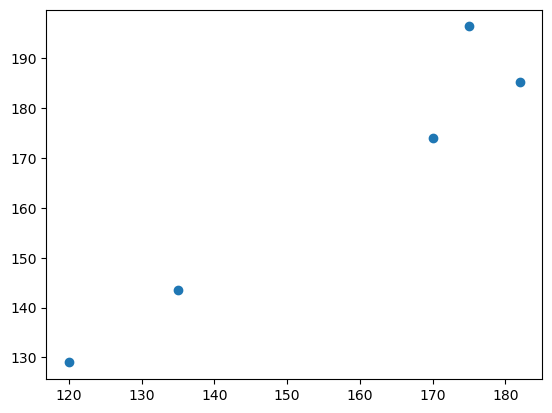

In [107]:
## Assumption
## Plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [108]:
## residuals
residuals = y_test - y_pred_test

In [113]:
residuals

0     -8.996473
17    -3.905012
15   -21.359281
1     -8.591748
8     -3.132147
Name: Height, dtype: float64

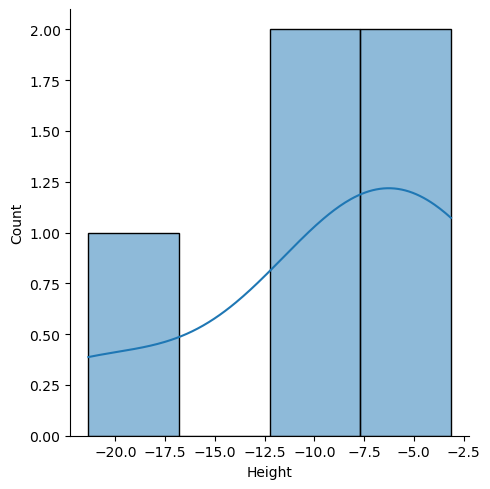

In [115]:
## plot this residuals
import seaborn as sns
sns.displot(residuals,kde=True)